In [1]:
!pip install scikeras==0.13.0

In [2]:
!pip install tensorflow

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.utils import to_categorical

from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import GridSearchCV


In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [5]:
def create_model(optimizer='adam', learning_rate=0.001, dropout_rate=0.0):
    if optimizer.lower() == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer.lower() == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer.lower() == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError("Unsupported optimizer")

    model = Sequential()
    model.add(Dense(512, activation='relu', input_shape=(28*28,)))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    model.add(Dense(256, activation='relu'))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [6]:
model = KerasClassifier(model=create_model, epochs=10, batch_size=128, verbose=1)

In [7]:
param_grid = {
    'model__optimizer': ['sgd', 'adam', 'rmsprop'],
    'model__learning_rate': [0.01, 0.001],
    'model__dropout_rate': [0.0, 0.2]
}

In [8]:
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1)
grid_result = grid.fit(X_train, y_train_cat)

print("Best Parameters:", grid_result.best_params_)
print("Best Accuracy:", grid_result.best_score_)

Epoch 1/10


C:\Users\janha\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9200 - loss: 0.2648
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9665 - loss: 0.1072
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9762 - loss: 0.0783
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9804 - loss: 0.0619
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9837 - loss: 0.0513
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9871 - loss: 0.0421
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9887 - loss: 0.0354
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9898 - loss: 0.0316
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9910 - loss: 0.0273
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9921 - loss: 0.0248
Best Parameters: {'model__dropout_rate': 0.2, 'model__learning_rate': 0.001, 'model__optimizer': 'rmsprop'}
Best Accuracy: 0.9775333333333333


In [9]:
histories = {}
optimizers = ['sgd', 'adam', 'rmsprop']

for opt in optimizers:
    print(f"Training with {opt.upper()} optimizer...")
    model = create_model(optimizer=opt, learning_rate=0.001, dropout_rate=0.2)
    history = model.fit(X_train, y_train_cat, 
                        validation_data=(X_test, y_test_cat),
                        epochs=15, batch_size=128, verbose=1)
    histories[opt] = history

Training with SGD optimizer...
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2460 - loss: 2.1910 - val_accuracy: 0.5102 - val_loss: 1.9944
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4946 - loss: 1.8860 - val_accuracy: 0.7016 - val_loss: 1.6659
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6302 - loss: 1.5852 - val_accuracy: 0.7678 - val_loss: 1.3491
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6987 - loss: 1.3131 - val_accuracy: 0.8055 - val_loss: 1.0889
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7362 - loss: 1.1044 - val_accuracy: 0.8293 - val_loss: 0.9011
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7636 - loss: 0.9567 - val_accuracy: 0.8443 - val_loss: 0.7703
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7848 - loss: 0.8439 - val_accuracy: 0.8562 - val_loss: 0.6789
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7981 - 

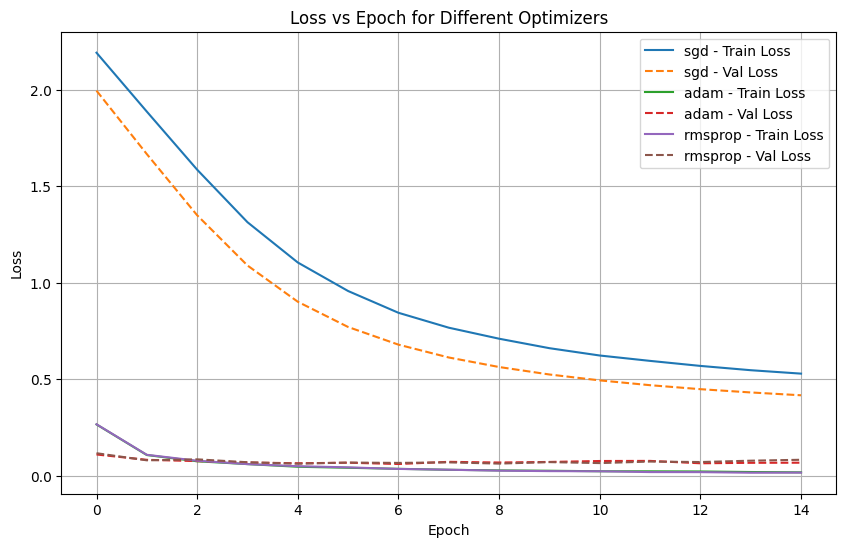

In [11]:
plt.figure(figsize=(10,6))
for opt in optimizers:
    plt.plot(histories[opt].history['loss'], label=f'{opt} - Train Loss')
    plt.plot(histories[opt].history['val_loss'], '--', label=f'{opt} - Val Loss')

plt.title('Loss vs Epoch for Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()



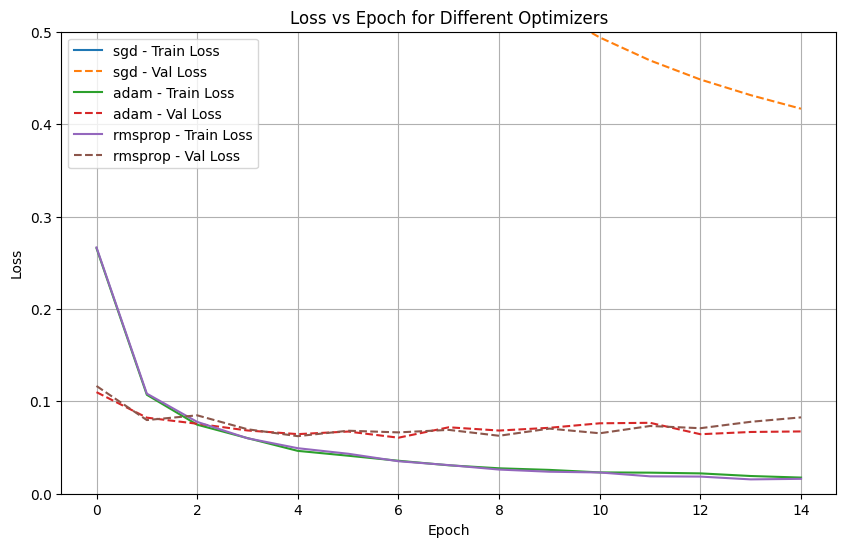

In [12]:
plt.figure(figsize=(10,6))

for opt in optimizers:
    if opt == 'SGD':
        continue  
    plt.plot(histories[opt].history['loss'], label=f'{opt} - Train Loss')
    plt.plot(histories[opt].history['val_loss'], '--', label=f'{opt} - Val Loss')

plt.title('Loss vs Epoch for Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, 0.5)  
plt.legend()
plt.grid(True)
plt.show()
